# How well do jobs and skills pay for Data Analysts? 

In [35]:
# importing libraries
import ast 
import pandas as pd 
from datasets import load_dataset 
import matplotlib.pyplot as plt 
import seaborn as sns

# loading the dataset
dataset = load_dataset('lukebarousse/data_jobs') 
df = dataset['train'].to_pandas() 

# data cleanup 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date']) 
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [36]:
df_India = df[(df['job_country'] == 'India')].dropna(subset=['salary_year_avg'])

In [37]:
job_titles = df_India['job_title_short'].value_counts().index[:6].tolist()

job_titles

['Data Engineer',
 'Data Analyst',
 'Data Scientist',
 'Machine Learning Engineer',
 'Senior Data Engineer',
 'Software Engineer']

In [38]:
df_India_top6 = df_India[df_India['job_title_short'].isin(job_titles)]

In [39]:
job_order = df_India_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

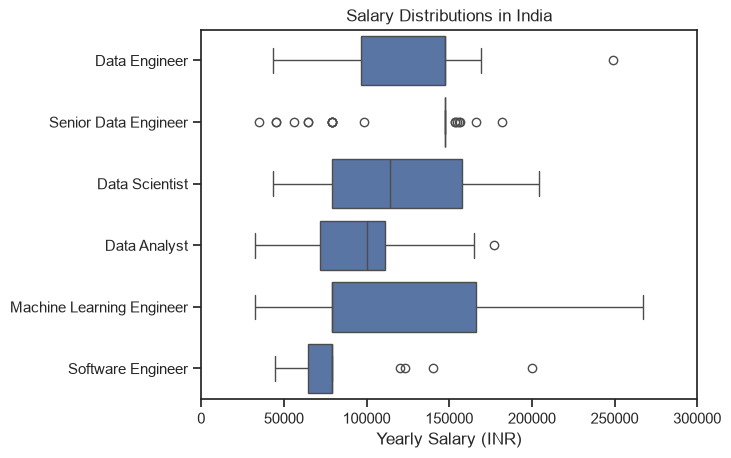

In [40]:
sns.boxplot(data=df_India_top6, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style='ticks')

plt.title('Salary Distributions in India')
plt.xlabel('Yearly Salary (INR)')
plt.ylabel('')
plt.xlim(0, 300000)
plt.show()

# Investigating Median Salary VS Skills for Data Analysts

In [ ]:
df_DA_India = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()
df_DA_India = df_DA_India.dropna(subset=['salary_year_avg'])

In [49]:
df_DA_India = df_DA_India.explode('job_skills')

In [50]:
df_DA_India_group = df_DA_India.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

In [51]:
df_DA_top_pay = df_DA_India_group[df_DA_India_group['count'] >= 5].sort_values(by='median', ascending=False).head(10)
df_DA_top_pay

,count,median
job_skills,,
mongodb,6,163782.0
looker,10,111175.0
spark,11,111175.0
powerpoint,10,111175.0
power bi,17,111175.0
tableau,20,108087.5
flow,6,102750.0
excel,39,98500.0
sql,46,96050.0


In [52]:
df_DA_skills = df_DA_India_group.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)
df_DA_skills

,count,median
job_skills,,
spark,11,111175.0
power bi,17,111175.0
tableau,20,108087.5
excel,39,98500.0
sql,46,96050.0
python,36,96050.0
azure,15,93600.0
r,18,79200.0
aws,12,79200.0


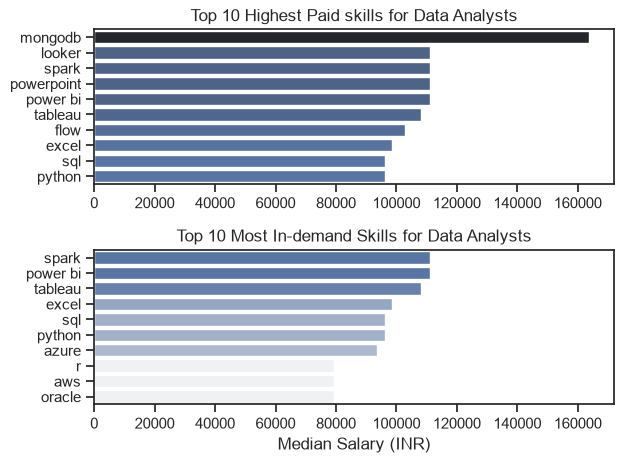

In [55]:
fig, ax = plt.subplots(2,1)

sns.set_theme(style="ticks")

sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=ax[0], hue='median', palette='dark:b_r', legend=False)
ax[0].set_title('Top 10 Highest Paid skills for Data Analysts')
ax[0].set_xlabel('')
ax[0].set_ylabel('')

sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, ax=ax[1], hue='median', palette='light:b', legend=False)
ax[1].set_title('Top 10 Most In-demand Skills for Data Analysts')
ax[1].set_xlabel('Median Salary (INR)')
ax[1].set_ylabel('')

ax[1].set_xlim(ax[0].get_xlim()) 
fig.tight_layout()